In [2]:
import torch
from torch import nn, optim
import numpy as np
import requests, gzip, os, hashlib, numpy
import matplotlib.pyplot as plt

In [3]:
def fetch(url):
    fp = os.path.join("/tmp", hashlib.md5(url.encode('utf-8')).hexdigest())
    if os.path.isfile(fp):
        with open(fp, "rb") as f:
            dat = f.read()
    else:
        with open(fp, "wb") as f:
            dat = requests.get(url).content
            f.write(dat)
    return np.frombuffer(gzip.decompress(dat), dtype=np.uint8).copy()
X_train = fetch("http://yann.lecun.com/exdb/mnist/train-images-idx3-ubyte.gz")[0x10:].reshape((-1, 28, 28))
Y_train = fetch("http://yann.lecun.com/exdb/mnist/train-labels-idx1-ubyte.gz")[8:]
X_test = fetch("http://yann.lecun.com/exdb/mnist/t10k-images-idx3-ubyte.gz")[0x10:].reshape((-1, 28, 28))
Y_test = fetch("http://yann.lecun.com/exdb/mnist/t10k-labels-idx1-ubyte.gz")[8:]

In [4]:
X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train)
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test)


(<matplotlib.image.AxesImage at 0x7f8050013f10>, tensor(3, dtype=torch.uint8))

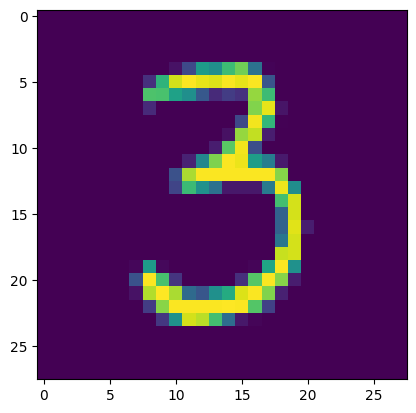

In [5]:
plt.imshow(X_train[50]),Y_train[50]

In [6]:
class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.layer1 = nn.Linear(784, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 10)
        
    def forward(self, x):
        x = nn.functional.relu(self.layer1(x))
        x = nn.functional.relu(self.layer2(x))
        x = nn.functional.log_softmax(self.layer3(x), dim=1)
        
        return x
        

In [7]:
model = Model()

loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
# training

for i in range(10000):
    optimizer.zero_grad()
    y_pred = model(X_train.view(-1, 784))
    
    loss = loss_function(y_pred,Y_train.long())
    
    loss.backward()
    optimizer.step()

    if i % 100 == 0:
        print(f"{i}: {loss}")

0: 10.88927173614502
100: 0.9374697804450989
200: 0.7573608160018921
300: 0.4314648509025574
400: 0.3569695055484772
500: 0.30320504307746887
600: 0.27166983485221863
700: 0.2501906454563141
800: 0.23536968231201172
900: 0.21012698113918304


In [28]:
correct = 0
total = X_test.shape[0]

In [29]:
for i in range(total):
    pred = model(X_test[i].view(-1, 784))
    pred = torch.argmax(pred)
    actual = Y_test[i]
    if pred.item() == actual.item():
        correct += 1

In [1]:
acc = correct / total

NameError: name 'correct' is not defined